In [4]:
import os

base_dirs = [
    "/kaggle/input/evaluate/Evaluation/ksavir/Scores",
    "/kaggle/input/evaluate/Evaluation/Lung_Xrays/Scores",
    "/kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Scores",
    "/kaggle/input/evaluate/Evaluation/ksavir/Model weights",
    "/kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Model_Saved_Weights",
    "/kaggle/input/evaluate/Evaluation/Lung_Xrays/Model Weights"
]

for dir_path in base_dirs:
    print(f"Contents of {dir_path}:")
    if os.path.exists(dir_path):
        print(os.listdir(dir_path))
    else:
        print("Directory does not exist.\n")

Contents of /kaggle/input/evaluate/Evaluation/ksavir/Scores:
['KvasirUnet_34_AG_scores.csv', 'KvasirUnet_34_SE_scores.csv', 'KvasirUnet_34_scores.csv', 'Kvasir_DeepLabV3_scores.csv', 'KvasirUnet_34_CBAM_scores.csv', 'KvasirUnet_50_scores.csv']
Contents of /kaggle/input/evaluate/Evaluation/Lung_Xrays/Scores:
['Lung_Unet_34_Scores.csv', 'Lung_Unet_34_SE_Scores.csv', 'Lung_Unet_34_AG_Scores.csv', 'Lung_Unet_34_CBAM_Scores.csv', 'Lung_Unet_50_Scores.csv', 'Lung_DeeplabV3_Scores.csv']
Contents of /kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Scores:
['Unet_resnet34_AG_scores.csv', 'CBAM_leasion_scores.csv', 'Unet_Resnet34_SE_Scores.csv']
Contents of /kaggle/input/evaluate/Evaluation/ksavir/Model weights:
['Kvasir_DeepLabV3_final.pth', 'KvasirUnet_50_best.pth', 'KvasirUnet_34_AG_best.pth', 'KvasirUnet_34_CBAM_final.pth', 'KvasirUnet_34_final.pth', 'KvasirUnet_34_SE_best.pth']
Contents of /kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Model_Saved_Weights:
['Unet_resne


=== Kvasir Dataset ===


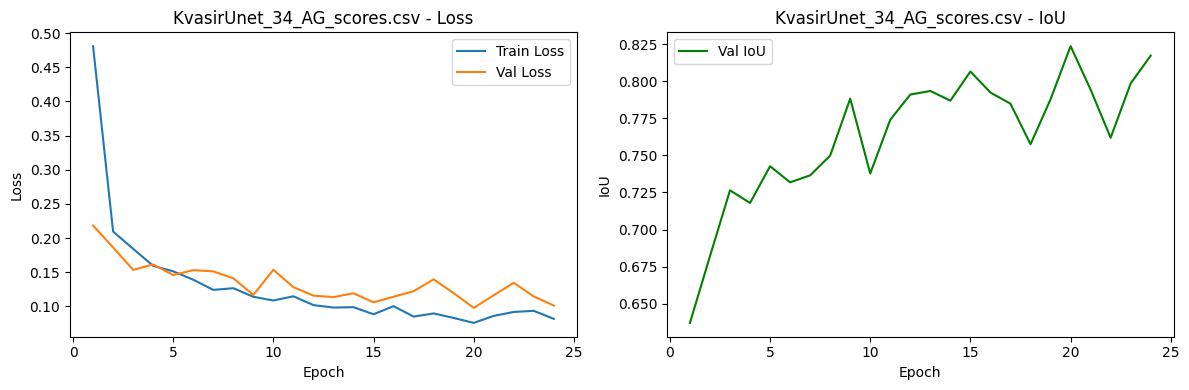

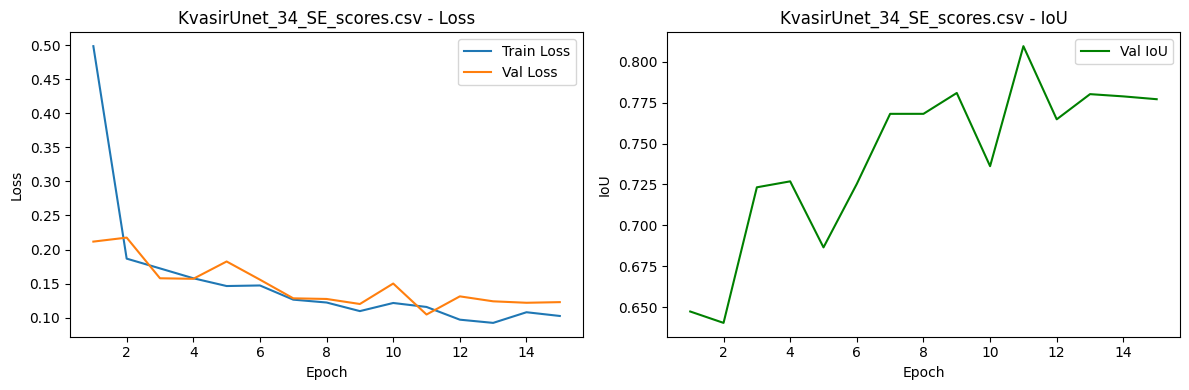

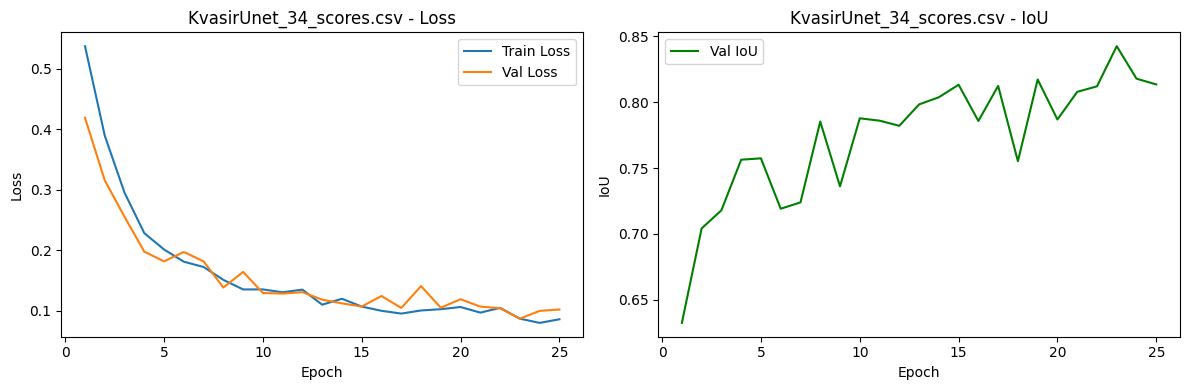

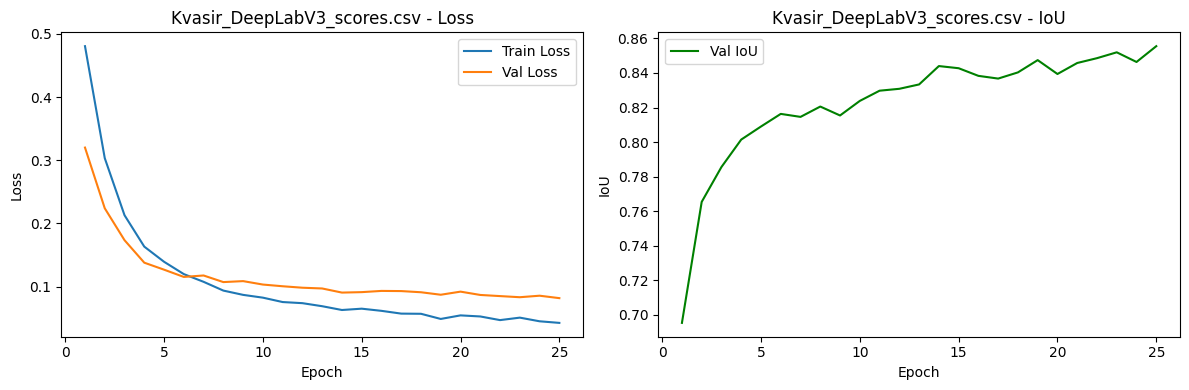

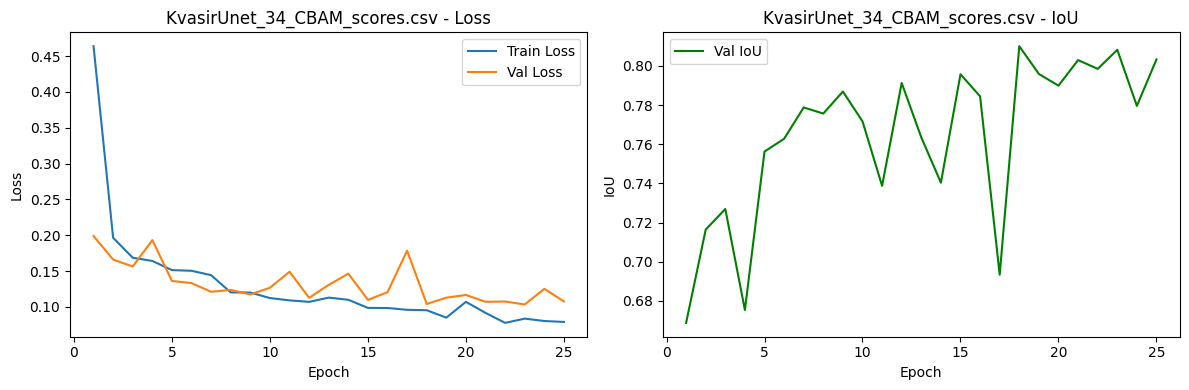

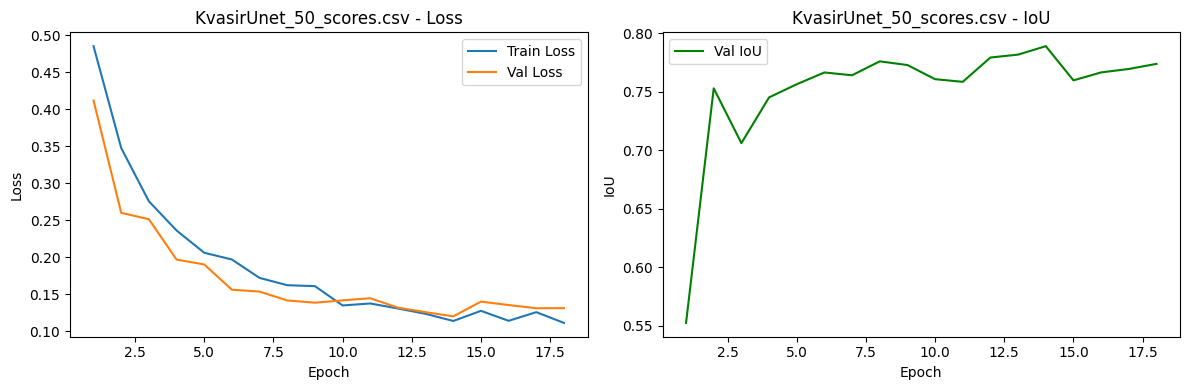


=== Lung Dataset ===


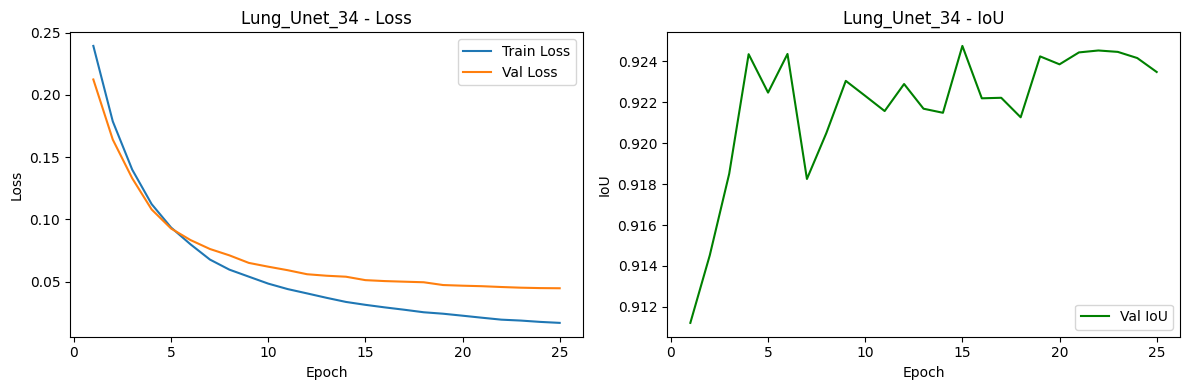

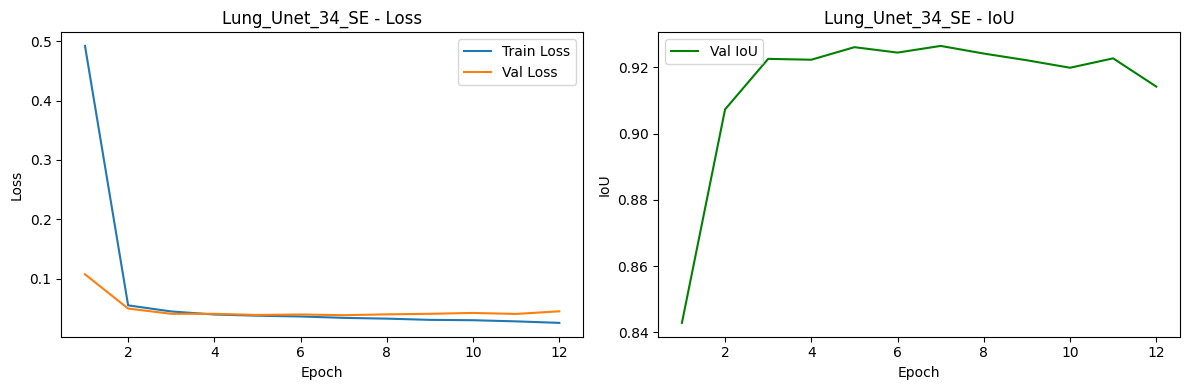

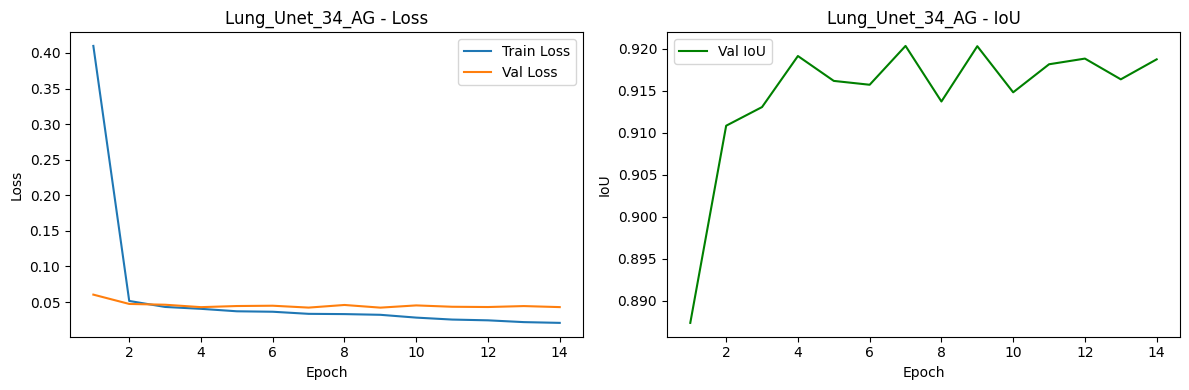

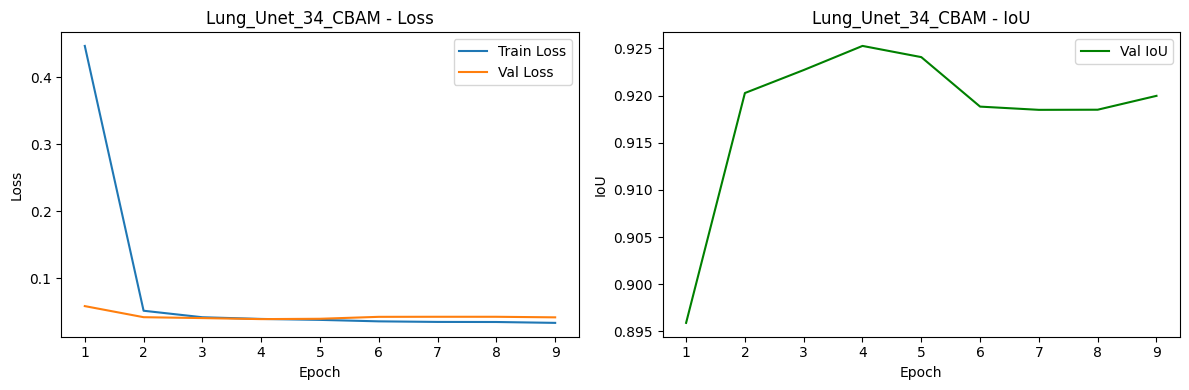

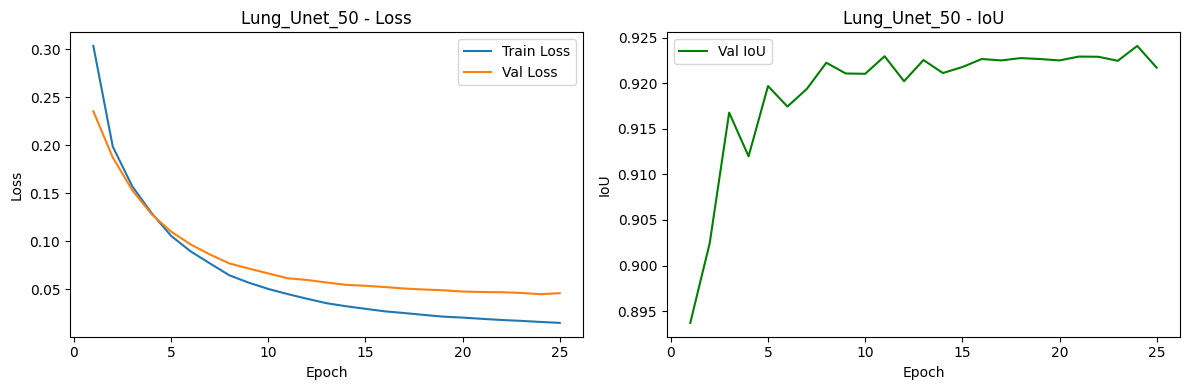

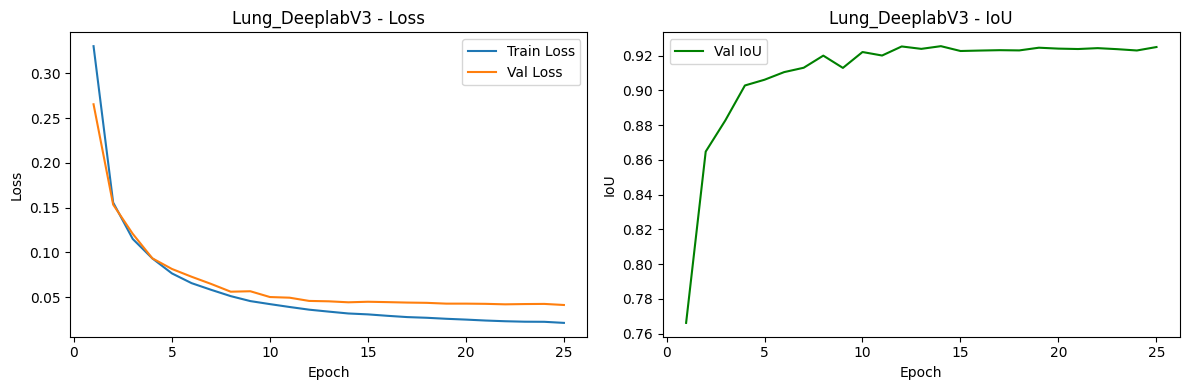


=== Skin Dataset ===


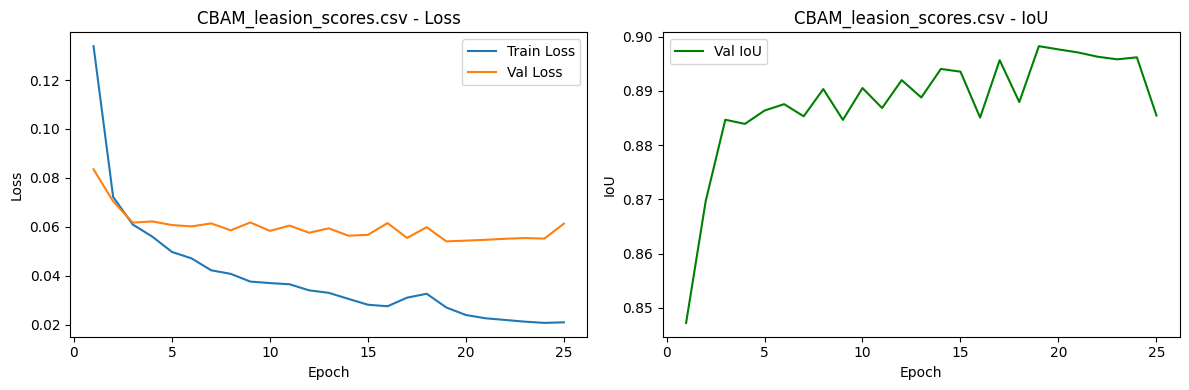

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

score_dirs = {
    "Kvasir": "/kaggle/input/evaluate/Evaluation/ksavir/Scores",
    "Lung": "/kaggle/input/evaluate/Evaluation/Lung_Xrays/Scores",
    "Skin": "/kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Scores"
}

for dataset_name, path in score_dirs.items():
    print(f"\n=== {dataset_name} Dataset ===")
    for file in os.listdir(path):
        if file.endswith(".csv"):
            if dataset_name == "Skin" and not (file.startswith("CBAM") or not file.startswith("Unet")):
                continue  # Skip CBAM, DeepLab, SE from skin dataset
            
            df = pd.read_csv(os.path.join(path, file))
            plt.figure(figsize=(12, 4))
            
            # Training vs Validation Loss
            plt.subplot(1, 2, 1)
            plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
            plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
            plt.title(f"{file.replace('_Scores.csv','')} - Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            
            # Validation IoU
            plt.subplot(1, 2, 2)
            if 'val_iou' in df.columns:
                plt.plot(df['epoch'], df['val_iou'], label='Val IoU', color='green')
                plt.title(f"{file.replace('_Scores.csv','')} - IoU")
                plt.xlabel("Epoch")
                plt.ylabel("IoU")
                plt.legend()
            
            plt.tight_layout()
            plt.show()

In [9]:
!pip install smp torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.7 MB/s eta 0:00:00
  Created wheel for crcmod: filename=crcmod-1.7-cp311-cp311-linux_x86_64.whl size=31656 sha256=e5fba206192487e9a667242c9663249a6e23101f1c00fa4ef57f0edb99b4b8f

In [16]:
import os
import pandas as pd

# Define the score directories
score_dirs = {
    "Kvasir": "/kaggle/input/evaluate/Evaluation/ksavir/Scores",
    "Lung": "/kaggle/input/evaluate/Evaluation/Lung_Xrays/Scores",
    "Skin": "/kaggle/input/evaluate/Evaluation/Skin_Lesion_Segmentation/Scores"
}

results = []

for dataset_name, path in score_dirs.items():
    for file in os.listdir(path):
        if file.endswith(".csv"):
            # Explicitly include only AG, CBAM, and SE for Skin
            if dataset_name == "Skin" and not (
                "AG" in file or "CBAM" in file or "SE" in file):
                continue

            df = pd.read_csv(os.path.join(path, file))
            last_iou = df["val_iou"].iloc[-1] if "val_iou" in df.columns else None
            if last_iou is not None:
                results.append({
                    "Dataset": dataset_name,
                    "Model": file.replace("_Scores.csv", "").replace("_scores.csv", "").replace(".csv", ""),
                    "Final IoU": round(last_iou, 4)
                })

# Create and display the table
score_df = pd.DataFrame(results)
score_df = score_df.sort_values(by=["Dataset", "Model"]).reset_index(drop=True)

# Display table
print(score_df)

# Optionally, save to file
# score_df.to_csv("/kaggle/working/final_model_iou_scores.csv", index=False)

   Dataset               Model  Final IoU
0   Kvasir       KvasirUnet_34     0.8134
1   Kvasir    KvasirUnet_34_AG     0.8174
2   Kvasir  KvasirUnet_34_CBAM     0.8034
3   Kvasir    KvasirUnet_34_SE     0.7771
4   Kvasir       KvasirUnet_50     0.7738
5   Kvasir    Kvasir_DeepLabV3     0.8555
6     Lung      Lung_DeeplabV3     0.9249
7     Lung        Lung_Unet_34     0.9235
8     Lung     Lung_Unet_34_AG     0.9188
9     Lung   Lung_Unet_34_CBAM     0.9200
10    Lung     Lung_Unet_34_SE     0.9142
11    Lung        Lung_Unet_50     0.9217
12    Skin        CBAM_leasion     0.8855
13    Skin    Unet_Resnet34_SE     0.8905
14    Skin    Unet_resnet34_AG     0.8890
